# Exploratory Data Analysis
**UPI Transaction Analytics & Risk Monitoring Platform**

Visualizes PaySim1: transaction types, fraud distribution, temporal trends, scatter patterns.

> Run `main.py` first to generate `data/processed/featured_data.csv`

In [1]:
%pip install --quiet scipy matplotlib pandas numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, chi2_contingency, skew

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',   'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E',      'ytick.color': '#8B949E',
    'text.color': '#C9D1D9',       'grid.color': '#21262D',
    'grid.alpha': 0.6,             'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D', 'font.family': 'DejaVu Sans',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
})
PALETTE = {
    'fraud': '#FF4757', 'legit': '#2ED573', 'medium': '#FFA502',
    'accent': '#1E90FF', 'purple': '#A855F7', 'teal': '#00BCD4',
    'bg_dark': '#0D1117', 'bg_card': '#161B22', 'border': '#30363D', 'text_muted': '#8B949E',
}
df_feat = pd.read_csv('../data/processed/featured_data.csv')
fraud_count = int(df_feat['isFraud'].sum())
legit_count = len(df_feat) - fraud_count
print(f"Loaded: {len(df_feat):,} rows  |  Fraud: {fraud_count:,}  ({fraud_count/len(df_feat)*100:.4f}%)")
df_feat.head(3)

Loaded: 44,414 rows  |  Fraud: 52  (0.1171%)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,orig_mean_amount,orig_std_amount,orig_total_sent,amount_z_score,orig_cv,dest_unique_senders,dest_tx_count,is_high_freq_dest,is_transfer,is_cash_out
0,45,TRANSFER,422698.88,C1403836777,20502.0,0.0,C355530332,1548167.20,1970866.1,0,...,422698.88,0.0,422698.88,0.0,0.0,1,1,0,1,0
1,20,CASH_OUT,283759.53,C813860567,6231.0,0.0,C603023442,1397807.90,1681567.4,0,...,283759.53,0.0,283759.53,0.0,0.0,1,1,0,0,1
2,9,CASH_OUT,262268.28,C204225557,104675.0,0.0,C426784026,76376.58,1674917.1,0,...,262268.28,0.0,262268.28,0.0,0.0,3,3,0,0,1


## 1. Transaction Types & Class Distribution

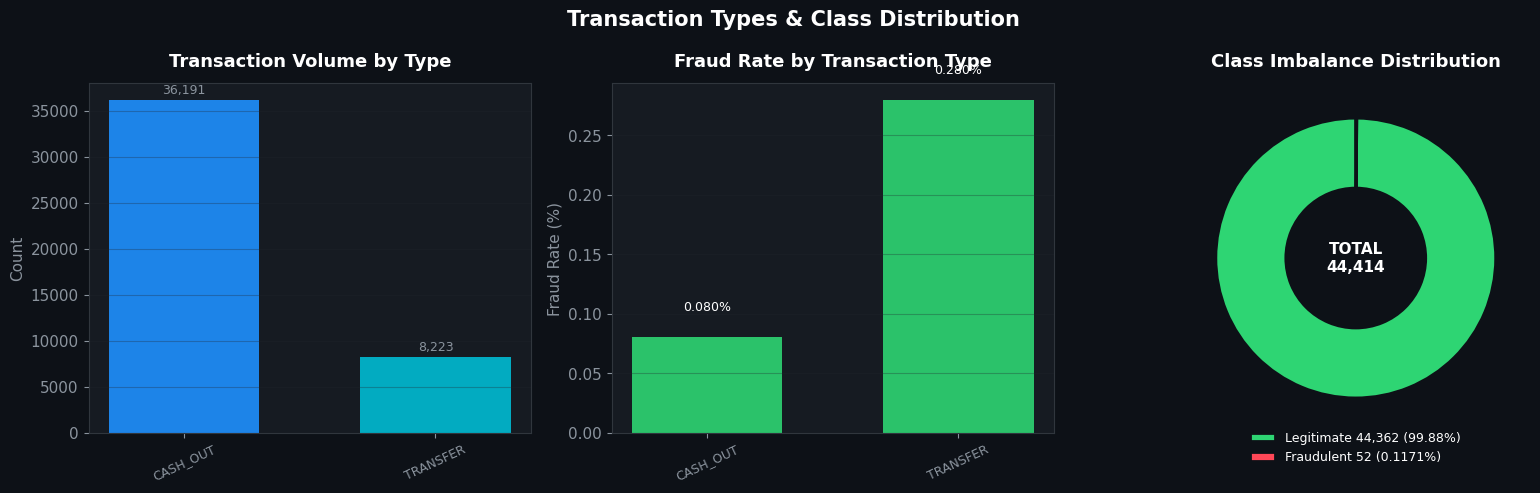

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Transaction Types & Class Distribution', fontsize=15, fontweight='bold', color='white')

ax = axes[0]
type_counts = df_feat['type'].value_counts()
colors = [PALETTE['accent'], PALETTE['teal'], PALETTE['fraud'], PALETTE['medium'], PALETTE['purple']]
bars = ax.bar(type_counts.index, type_counts.values, color=colors[:len(type_counts)], alpha=0.9, width=0.6)
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(type_counts)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=9, color=PALETTE['text_muted'])
ax.set_title('Transaction Volume by Type', color='white')
ax.set_ylabel('Count', color=PALETTE['text_muted'])
ax.tick_params(axis='x', rotation=25, labelsize=9)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
fraud_by_type = df_feat.groupby('type')['isFraud'].mean() * 100
bar_colors = [PALETTE['fraud'] if v > 0.5 else PALETTE['legit'] for v in fraud_by_type.values]
bars2 = ax.bar(fraud_by_type.index, fraud_by_type.values, color=bar_colors, alpha=0.9, width=0.6)
for bar, val in zip(bars2, fraud_by_type.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=9, color='white')
ax.set_title('Fraud Rate by Transaction Type', color='white')
ax.set_ylabel('Fraud Rate (%)', color=PALETTE['text_muted'])
ax.tick_params(axis='x', rotation=25, labelsize=9)
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
wedges, _ = ax.pie([legit_count, fraud_count],
    colors=[PALETTE['legit'], PALETTE['fraud']], startangle=90,
    wedgeprops=dict(width=0.5, edgecolor=PALETTE['bg_dark'], linewidth=2))
ax.text(0, 0, f'TOTAL\n{len(df_feat):,}', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')
labels_pie = [f'Legitimate {legit_count:,} ({legit_count/len(df_feat)*100:.2f}%)',
              f'Fraudulent {fraud_count:,} ({fraud_count/len(df_feat)*100:.4f}%)']
ax.legend(wedges, labels_pie, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          fontsize=9, ncol=1, framealpha=0, labelcolor='white')
ax.set_title('Class Imbalance Distribution', color='white')
plt.tight_layout()
plt.show()

## 2. Amount Distribution: Fraud vs Legitimate

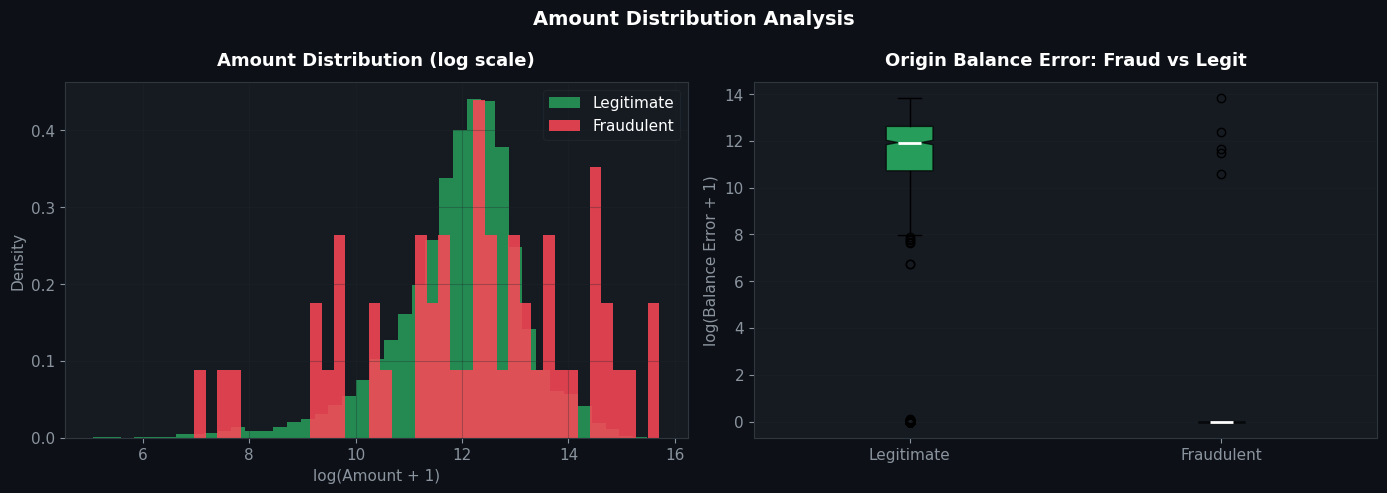


  [FRAUD]  Mean=Rs.833,078  Median=Rs.248,608  Max=Rs.6,648,390  Skew=2.530

  [LEGITIMATE]  Mean=Rs.268,497  Median=Rs.177,527  Max=Rs.6,419,836  Skew=4.005


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Amount Distribution Analysis', fontsize=14, fontweight='bold', color='white')

ax = axes[0]
sample_legit = df_feat[df_feat['isFraud']==0]['log_amount'].sample(
    min(5000,(df_feat['isFraud']==0).sum()), random_state=42)
fraud_log = df_feat[df_feat['isFraud']==1]['log_amount']
ax.hist(sample_legit, bins=40, alpha=0.6, color=PALETTE['legit'],
        label='Legitimate', density=True, edgecolor='none')
ax.hist(fraud_log, bins=40, alpha=0.85, color=PALETTE['fraud'],
        label='Fraudulent', density=True, edgecolor='none')
ax.set_title('Amount Distribution (log scale)', color='white')
ax.set_xlabel('log(Amount + 1)', color=PALETTE['text_muted'])
ax.set_ylabel('Density', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)

ax = axes[1]
err_fraud = df_feat[df_feat['isFraud']==1]['origin_balance_error'].clip(0, 1e6)
err_legit = df_feat[df_feat['isFraud']==0]['origin_balance_error'].clip(0, 1e6)
data_box = [np.log1p(err_legit.sample(min(1000,len(err_legit)), random_state=42)), np.log1p(err_fraud)]
bp = ax.boxplot(data_box, labels=['Legitimate','Fraudulent'], patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set(facecolor=PALETTE['legit'], alpha=0.7)
bp['boxes'][1].set(facecolor=PALETTE['fraud'], alpha=0.7)
ax.set_title('Origin Balance Error: Fraud vs Legit', color='white')
ax.set_ylabel('log(Balance Error + 1)', color=PALETTE['text_muted'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for group, label in [(1,'FRAUD'), (0,'LEGITIMATE')]:
    amounts = df_feat[df_feat['isFraud']==group]['amount']
    print(f"\n  [{label}]  Mean=Rs.{amounts.mean():,.0f}  Median=Rs.{amounts.median():,.0f}  Max=Rs.{amounts.max():,.0f}  Skew={skew(amounts):.3f}")

## 3. Temporal Patterns

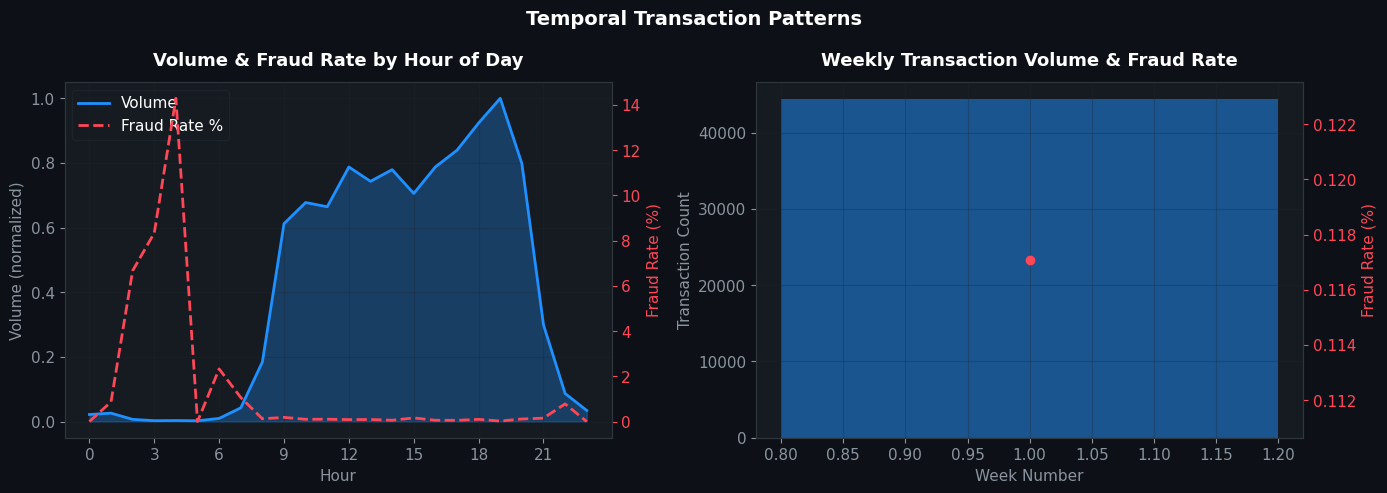

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Temporal Transaction Patterns', fontsize=14, fontweight='bold', color='white')

ax = axes[0]
hourly = df_feat.groupby('hour_of_day').agg(tx_count=('isFraud','count'), fraud_count=('isFraud','sum'))
hourly['fraud_rate'] = hourly['fraud_count'] / hourly['tx_count'] * 100
norm_vol = hourly['tx_count'] / hourly['tx_count'].max()
ax.fill_between(hourly.index, norm_vol, alpha=0.3, color=PALETTE['accent'])
ax.plot(hourly.index, norm_vol, color=PALETTE['accent'], linewidth=2)
ax_r = ax.twinx()
ax_r.plot(hourly.index, hourly['fraud_rate'], color=PALETTE['fraud'], linewidth=2, linestyle='--')
ax_r.tick_params(colors=PALETTE['fraud'])
ax_r.set_ylabel('Fraud Rate (%)', color=PALETTE['fraud'])
ax.set_title('Volume & Fraud Rate by Hour of Day', color='white')
ax.set_xlabel('Hour', color=PALETTE['text_muted'])
ax.set_ylabel('Volume (normalized)', color=PALETTE['text_muted'])
ax.set_xticks(range(0, 24, 3))
lines = [Line2D([0],[0],color=PALETTE['accent'],lw=2), Line2D([0],[0],color=PALETTE['fraud'],lw=2,ls='--')]
ax.legend(lines, ['Volume', 'Fraud Rate %'], labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)

ax = axes[1]
weekly = df_feat.groupby('week_number').agg(tx_count=('isFraud','count'), fraud_count=('isFraud','sum')).reset_index()
weekly['fraud_rate'] = weekly['fraud_count'] / weekly['tx_count'] * 100
ax.bar(weekly['week_number'], weekly['tx_count'], color=PALETTE['accent'], alpha=0.5, width=0.4)
ax_r2 = ax.twinx()
ax_r2.plot(weekly['week_number'], weekly['fraud_rate'], color=PALETTE['fraud'], linewidth=2, marker='o', markersize=6)
ax_r2.tick_params(colors=PALETTE['fraud'])
ax_r2.set_ylabel('Fraud Rate (%)', color=PALETTE['fraud'])
ax.set_title('Weekly Transaction Volume & Fraud Rate', color='white')
ax.set_xlabel('Week Number', color=PALETTE['text_muted'])
ax.set_ylabel('Transaction Count', color=PALETTE['text_muted'])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Scatter Analysis — Amount vs Balance Drain

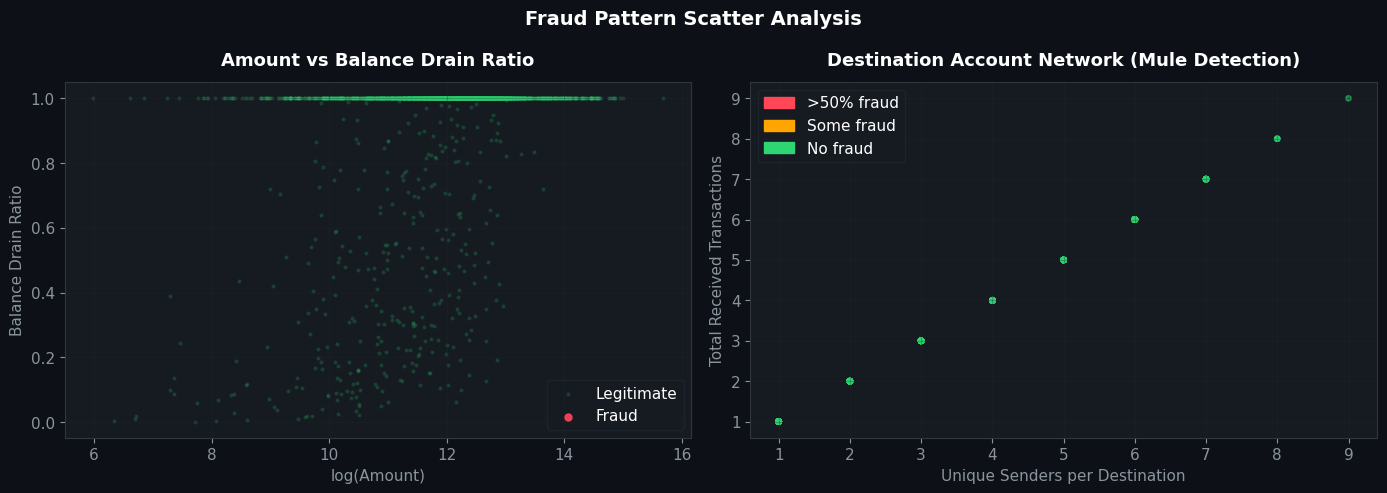

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Fraud Pattern Scatter Analysis', fontsize=14, fontweight='bold', color='white')

ax = axes[0]
sample = df_feat.sample(min(3000, len(df_feat)), random_state=42)
ax.scatter(sample[sample['isFraud']==0]['log_amount'],
           sample[sample['isFraud']==0]['balance_drain_ratio'],
           c=PALETTE['legit'], alpha=0.2, s=8, linewidths=0, label='Legitimate')
ax.scatter(sample[sample['isFraud']==1]['log_amount'],
           sample[sample['isFraud']==1]['balance_drain_ratio'],
           c=PALETTE['fraud'], alpha=0.9, s=25, zorder=5, label='Fraud')
ax.set_xlabel('log(Amount)', color=PALETTE['text_muted'])
ax.set_ylabel('Balance Drain Ratio', color=PALETTE['text_muted'])
ax.set_title('Amount vs Balance Drain Ratio', color='white')
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)

ax = axes[1]
dest_agg = df_feat.groupby('nameDest').agg(
    senders=('nameOrig','nunique'), fraud_received=('isFraud','sum'), total_txns=('isFraud','count')).reset_index()
dest_agg['fraud_rate'] = dest_agg['fraud_received'] / dest_agg['total_txns']
c_mule = [PALETTE['fraud'] if r > 0.5 else (PALETTE['medium'] if r > 0 else PALETTE['legit'])
          for r in dest_agg['fraud_rate']]
ax.scatter(dest_agg['senders'].clip(0,20), dest_agg['total_txns'].clip(0,30), c=c_mule, alpha=0.5, s=15)
ax.set_xlabel('Unique Senders per Destination', color=PALETTE['text_muted'])
ax.set_ylabel('Total Received Transactions', color=PALETTE['text_muted'])
ax.set_title('Destination Account Network (Mule Detection)', color='white')
legend_els = [mpatches.Patch(color=PALETTE['fraud'],  label='>50% fraud'),
              mpatches.Patch(color=PALETTE['medium'], label='Some fraud'),
              mpatches.Patch(color=PALETTE['legit'],  label='No fraud')]
ax.legend(handles=legend_els, labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Statistical Tests

In [7]:
print("Mann-Whitney U Tests (Fraud vs Legitimate)")
print(f"  {'Feature':<35} {'U Statistic':>15} {'p-value':>12} {'Significant?':>12}")
print("  " + "-"*76)
for feat in ['balance_drain_ratio','origin_balance_error','dest_balance_error',
             'amount_z_score','log_amount','dest_unique_senders']:
    u, p = mannwhitneyu(df_feat[df_feat['isFraud']==1][feat].dropna(),
                        df_feat[df_feat['isFraud']==0][feat].dropna(), alternative='two-sided')
    sig = "YES ***" if p < 0.05 else "NO"
    print(f"  {feat:<35} {u:>15,.0f} {p:>12.4e} {sig:>12}")

print("\nChi-Square Tests for Binary Features")
print(f"  {'Feature':<35} {'chi2':>10} {'p-value':>12} {'Verdict':>15}")
print("  " + "-"*74)
for feat in ['is_account_drained','dest_balance_unchanged','has_origin_error','both_balances_wrong','is_off_hours']:
    ct = pd.crosstab(df_feat[feat], df_feat['isFraud'])
    chi2, p, _, _ = chi2_contingency(ct)
    verdict = "DEPENDENT ***" if p < 0.05 else "INDEPENDENT"
    print(f"  {feat:<35} {chi2:>10.2f} {p:>12.4e} {verdict:>15}")

Mann-Whitney U Tests (Fraud vs Legitimate)
  Feature                                 U Statistic      p-value Significant?
  ----------------------------------------------------------------------------
  balance_drain_ratio                       1,279,616   1.1677e-02      YES ***
  origin_balance_error                        186,754   1.2779e-25      YES ***
  dest_balance_error                        1,560,950   1.9468e-06      YES ***
  amount_z_score                            1,153,412   1.0000e+00           NO
  log_amount                                1,315,119   8.0113e-02           NO
  dest_unique_senders                         989,500   5.7434e-02           NO

Chi-Square Tests for Binary Features
  Feature                                   chi2      p-value         Verdict
  --------------------------------------------------------------------------
  is_account_drained                        5.31   2.1163e-02   DEPENDENT ***
  dest_balance_unchanged                 2548.9